In [3]:
#Comparing the methods when extracting chords from a MIDI file and audio
from mixed_techniques_chord_analyser import *
from chordAnalyzer import *
from IPython.display import display, Markdown, Audio

# Song ID (used for both MIDI and audio paths)
# song_id = "2cfba915-9d1d-41dc-92bb-729118ef6694"
song_id = "d28b5089-761c-456c-83df-499bb703ca39"

# 1. Setup paths
base_path = "../samples/suno_samples"
audio_path = f"{base_path}/audio/{song_id}.mp3"
midi_base_path = f"{base_path}/segmented/{song_id}/midi"
bass_midi_path = f"{midi_base_path}/bass.mid"
harmony_midi_path = f"{midi_base_path}/harmony.mid"

bpm = get_bpm_from_audio(audio_path)
print(  f"BPM: {bpm}")

bass_notes = load_midi_notes(bass_midi_path, source_name='bass')
harmony_notes = load_midi_notes(harmony_midi_path, source_name='harmony')
combined_notes = bass_notes + harmony_notes
combined_notes.sort(key=lambda x: x['start'])

chords_midi = extract_all_chords_with_defined_length(combined_notes, bpm, window_size_beats=1, merge=True, verbose=True, plot=False)
print(len(chords_midi))


BPM: 83.35433467741936
Loading MIDI file: ../samples/suno_samples/segmented/d28b5089-761c-456c-83df-499bb703ca39/midi/bass.mid
Extracted 551 notes from ../samples/suno_samples/segmented/d28b5089-761c-456c-83df-499bb703ca39/midi/bass.mid
Loading MIDI file: ../samples/suno_samples/segmented/d28b5089-761c-456c-83df-499bb703ca39/midi/harmony.mid
Extracted 1182 notes from ../samples/suno_samples/segmented/d28b5089-761c-456c-83df-499bb703ca39/midi/harmony.mid
97


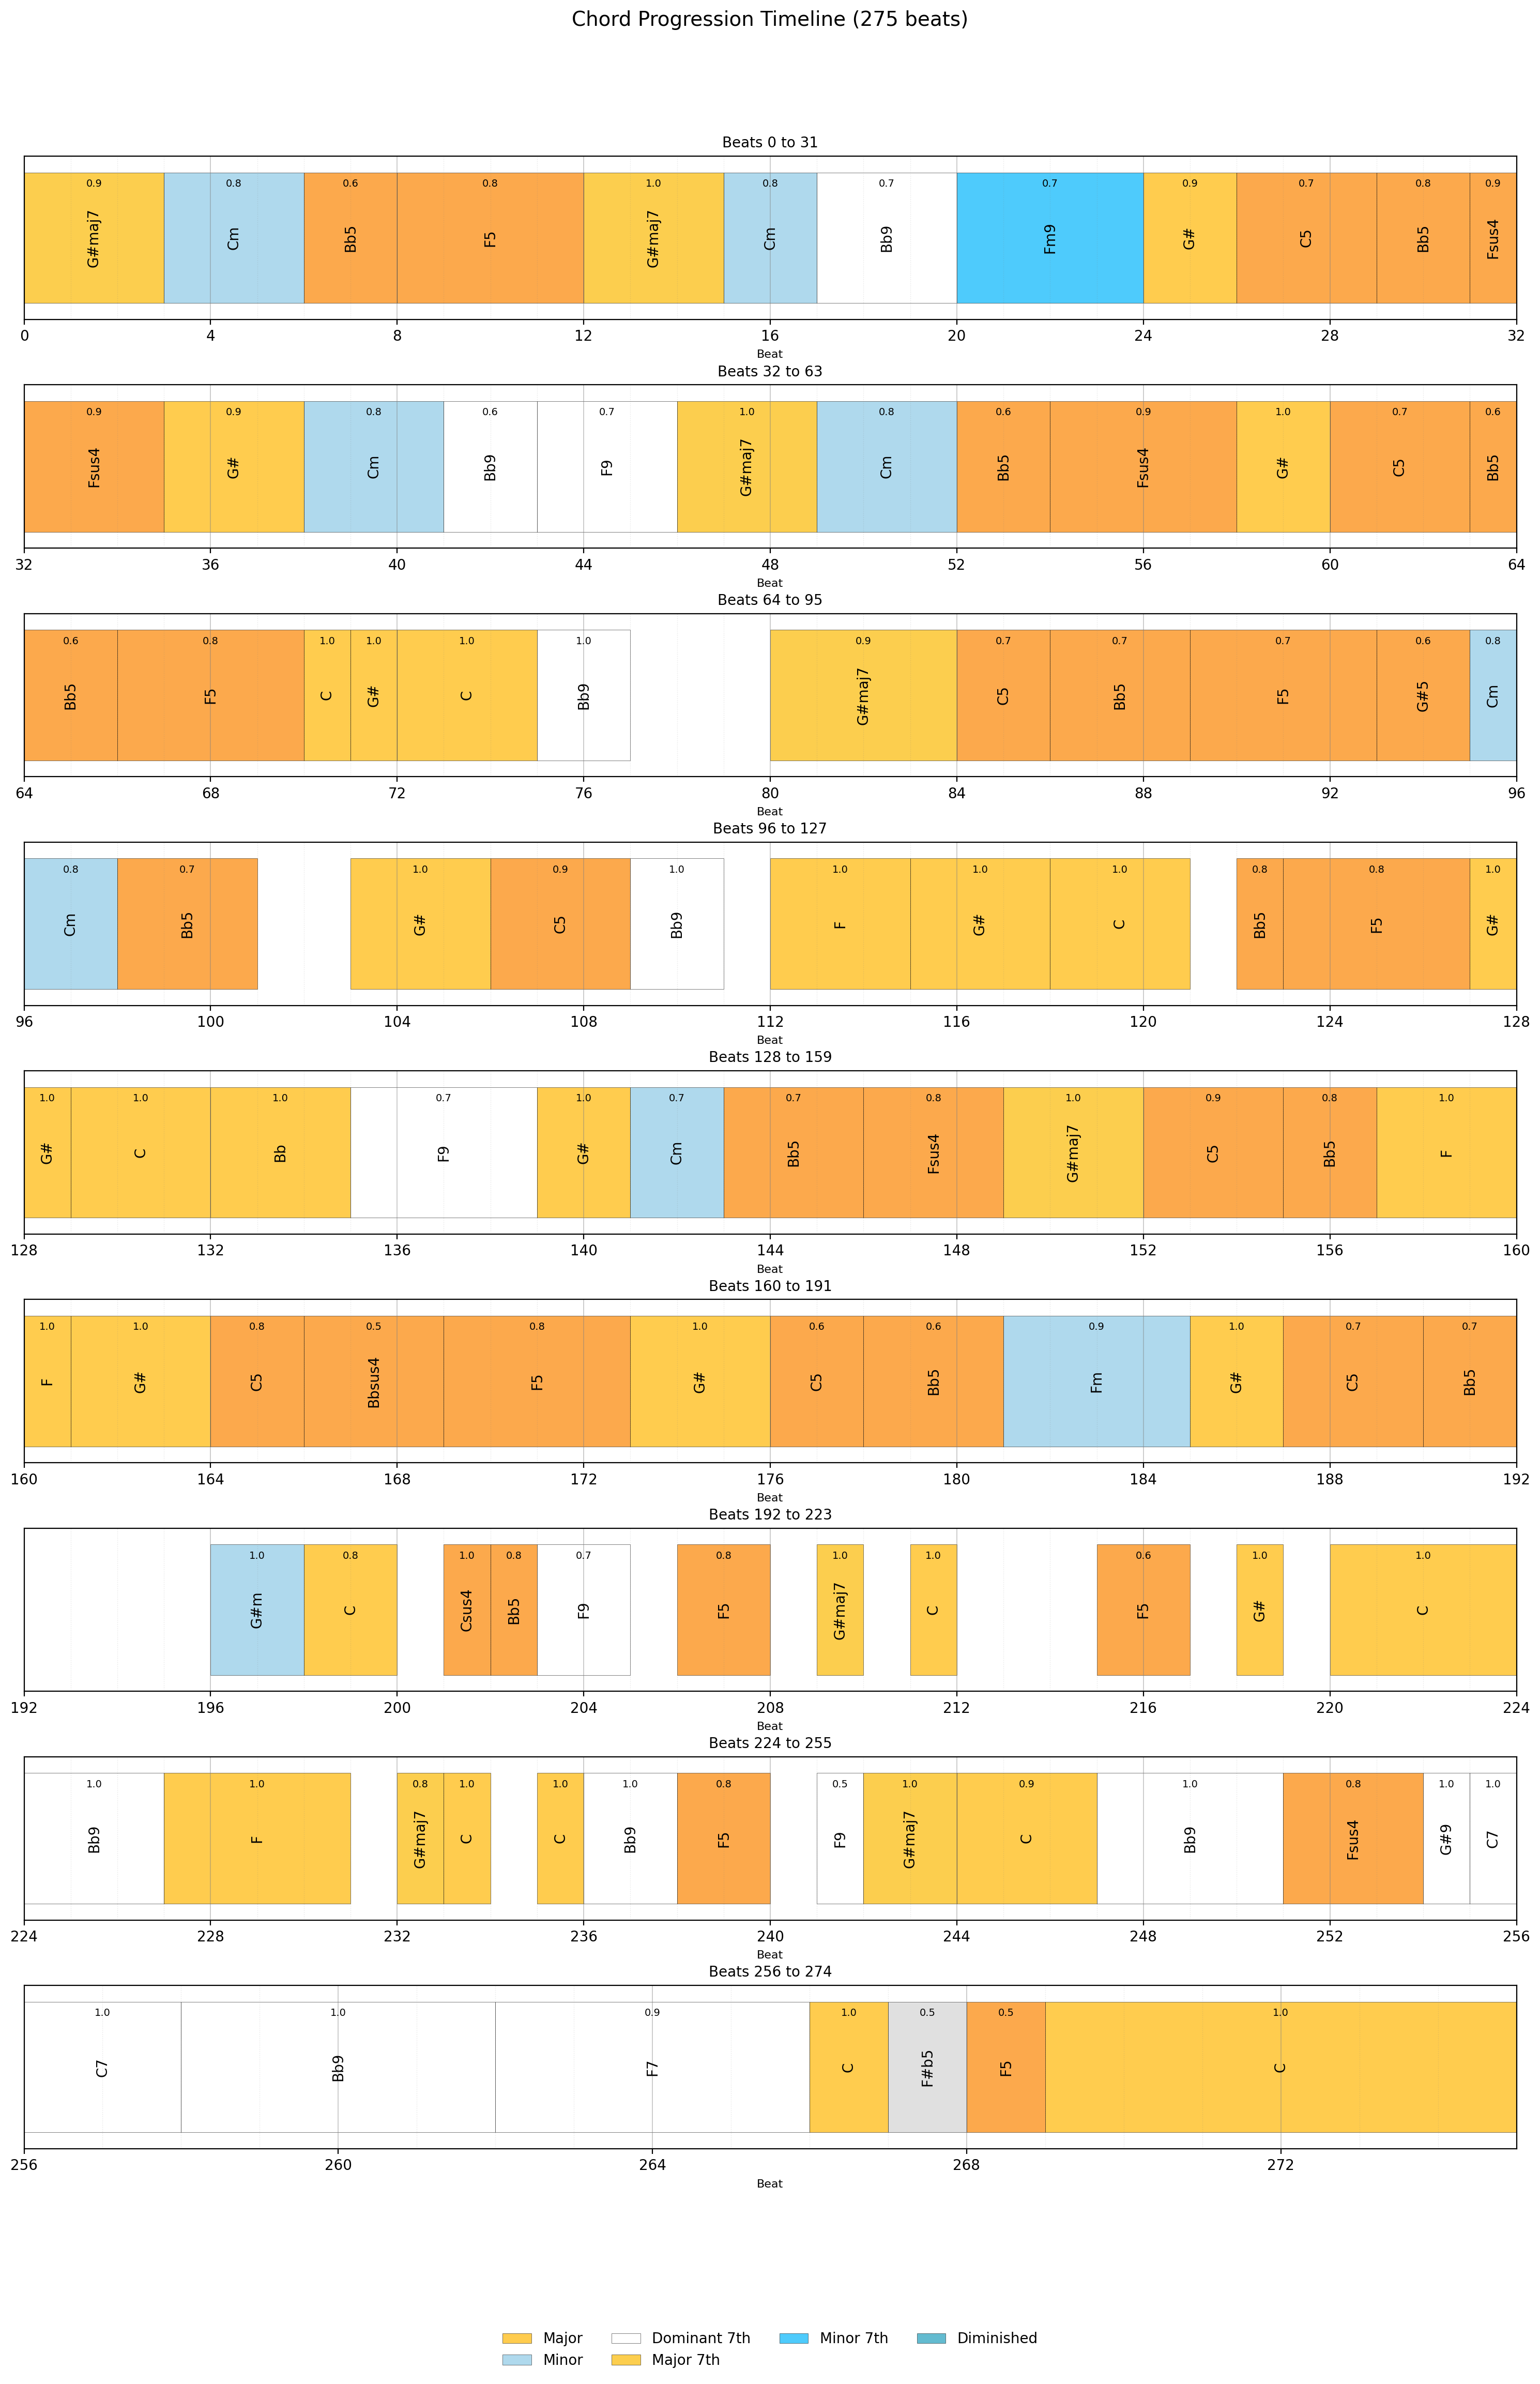

Visualization saved as: chord_progression.pdf


In [4]:
from chordAnalyzer import plot_chord_timeline, plot_chord_timeline_multirow

# Calculate total beats from the last chord's end
total_beats = int(max(c['beat_end'] for c in chords_midi))

# Option 2: Multi-row timeline (better for long pieces)
plot_chord_timeline_multirow(chords_midi, total_beats=total_beats, beats_per_row=32)


In [5]:
import triadExtractor as te
from transposition import Transposition

# Initialize the Transposition object
transposer = Transposition()

# Create an instance of TriadExtractor first
extractor = te.TriadExtractor(hop_length=1024)

tonality = extractor.getTonality(audio_path)

# Use the get_alterations_scales method to get alterations
tonality, alterations, scale = transposer.get_alterations_scales(tonality)

triads = te.TriadExtractor(hop_length=1024, scale=scale)
chords_audio = triads.extract_chords(audio_path, threshold=0.05, check_on_beat=True)
print(tonality, alterations, scale)


F minor ['Bb', 'Eb', 'Ab', 'Db'] ['F', 'G', 'Ab', 'Bb', 'C', 'Db', 'Eb']


In [6]:
chords_audio= correct_enharmonics(chords_audio, tonality, alterations, scale)
chords_midi = correct_enharmonics(chords_midi, tonality, alterations, scale)
print(chords_audio)
print(chords_midi)

[ChordChange(chord='Ab', timestamp=0.09287981859410431), ChordChange(chord='Cm7', timestamp=1.7182766439909296), ChordChange(chord='Bb', timestamp=2.8328344671201813), ChordChange(chord='F', timestamp=4.504671201814059), ChordChange(chord='Fm', timestamp=5.61922902494331), ChordChange(chord='Ab', timestamp=6.640907029478458), ChordChange(chord='Cm', timestamp=7.198185941043084), ChordChange(chord='Bb', timestamp=8.870022675736962), ChordChange(chord='F7', timestamp=9.984580498866213), ChordChange(chord='Abmaj7', timestamp=11.702857142857143), ChordChange(chord='Cm', timestamp=12.910294784580499), ChordChange(chord='C', timestamp=13.514013605442177), ChordChange(chord='Cm', timestamp=14.117732426303855), ChordChange(chord='Bb', timestamp=14.628571428571428), ChordChange(chord='Fmaj7', timestamp=15.789569160997733), ChordChange(chord='Fm', timestamp=16.950566893424035), ChordChange(chord='Abmaj7', timestamp=17.507845804988662), ChordChange(chord='Cm', timestamp=18.622403628117915), Chord

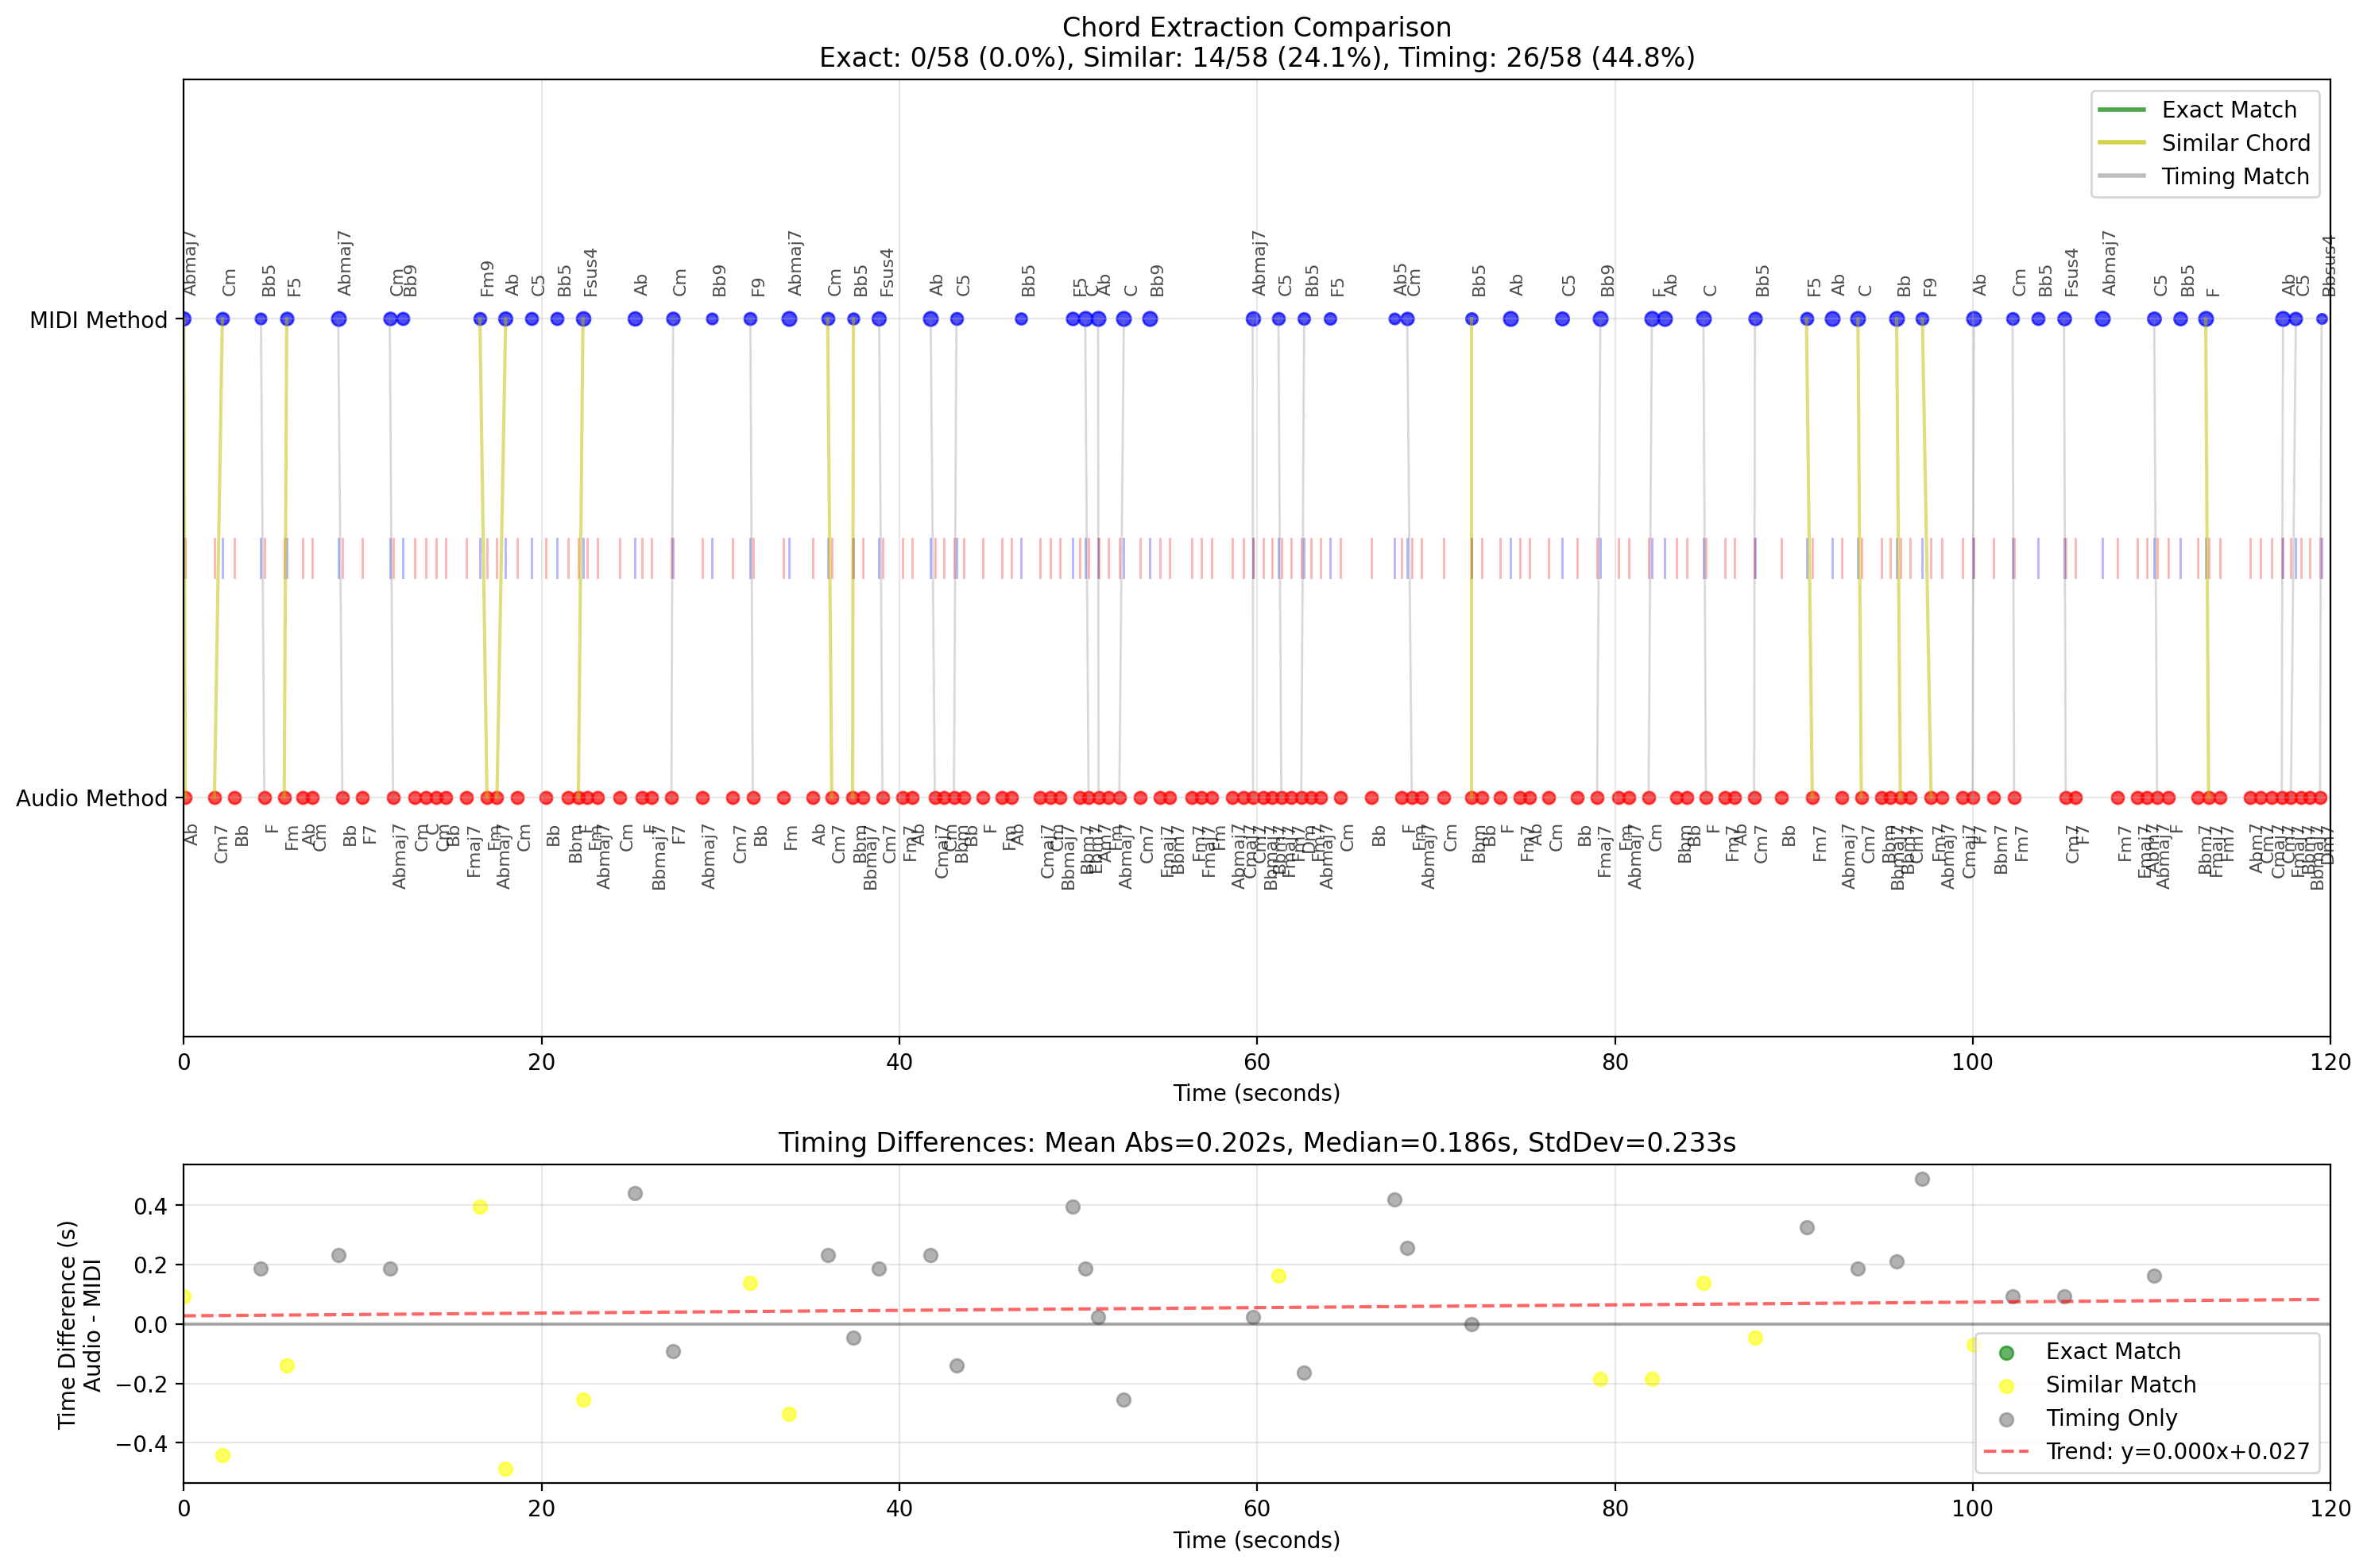

Comparison summary: Methods show significant disagreement
Audio method detects more chords
Good timing precision between methods


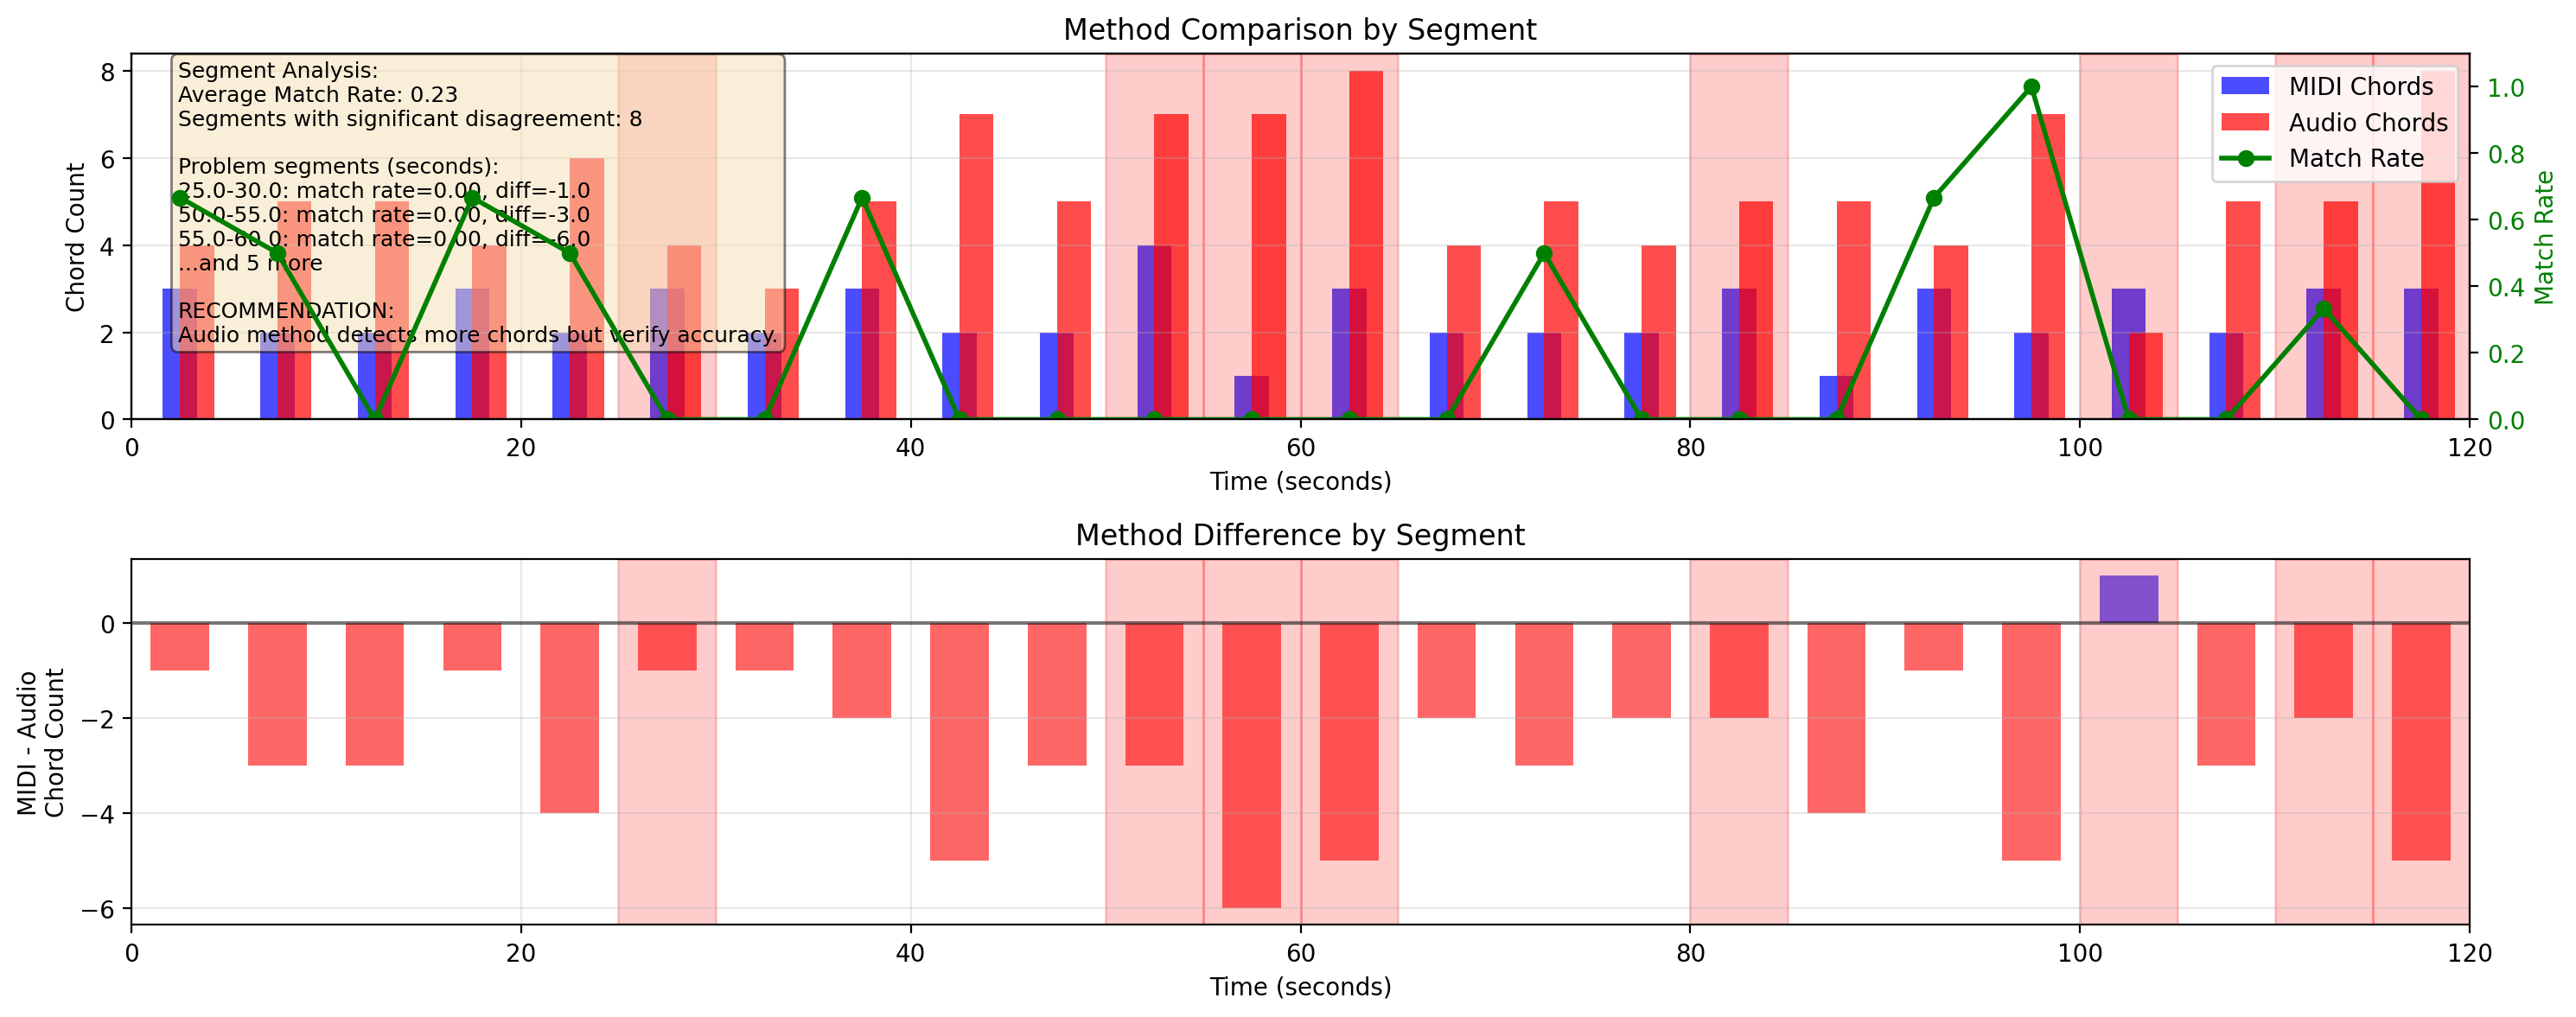

In [7]:
# For a complete comparison with timing analysis
stats = compare_chord_extractions(chords_midi, chords_audio)
print(f"Comparison summary: {stats['conclusion']}")

# For segment-by-segment analysis to pinpoint disagreements
segment_analysis = analyze_chord_progression_segments(chords_midi, chords_audio, segment_size=5)

[{'beat_start': 0, 'beat_end': 3, 'root': 'Ab', 'chord_type': 'maj7', 'chord_name': 'Abmaj7', 'intervals': [0, 11, 4, 7], 'source': 'bass-confirmed', 'confidence': 0.8888888888888888, 'timestamp': 0.0, 'duration': 3}, {'beat_start': 3, 'beat_end': 6, 'root': 'C', 'chord_type': 'm', 'chord_name': 'Cm', 'intervals': [0, 3, 7], 'source': 'bass-confirmed', 'confidence': 0.7608695652173914, 'timestamp': 2.159455782312925, 'duration': 3}, {'beat_start': 6, 'beat_end': 8, 'root': 'Bb', 'chord_type': '5', 'chord_name': 'Bb5', 'intervals': [0, 7, 4], 'source': 'bass-confirmed', 'confidence': 0.5957446808510638, 'timestamp': 4.31891156462585, 'duration': 2}, {'beat_start': 8, 'beat_end': 12, 'root': 'F', 'chord_type': '5', 'chord_name': 'F5', 'intervals': [0, 7], 'source': 'bass-confirmed', 'confidence': 0.8043478260869565, 'timestamp': 5.758548752834467, 'duration': 4}, {'beat_start': 12, 'beat_end': 15, 'root': 'Ab', 'chord_type': 'maj7', 'chord_name': 'Abmaj7', 'intervals': [0, 4, 11], 'sourc

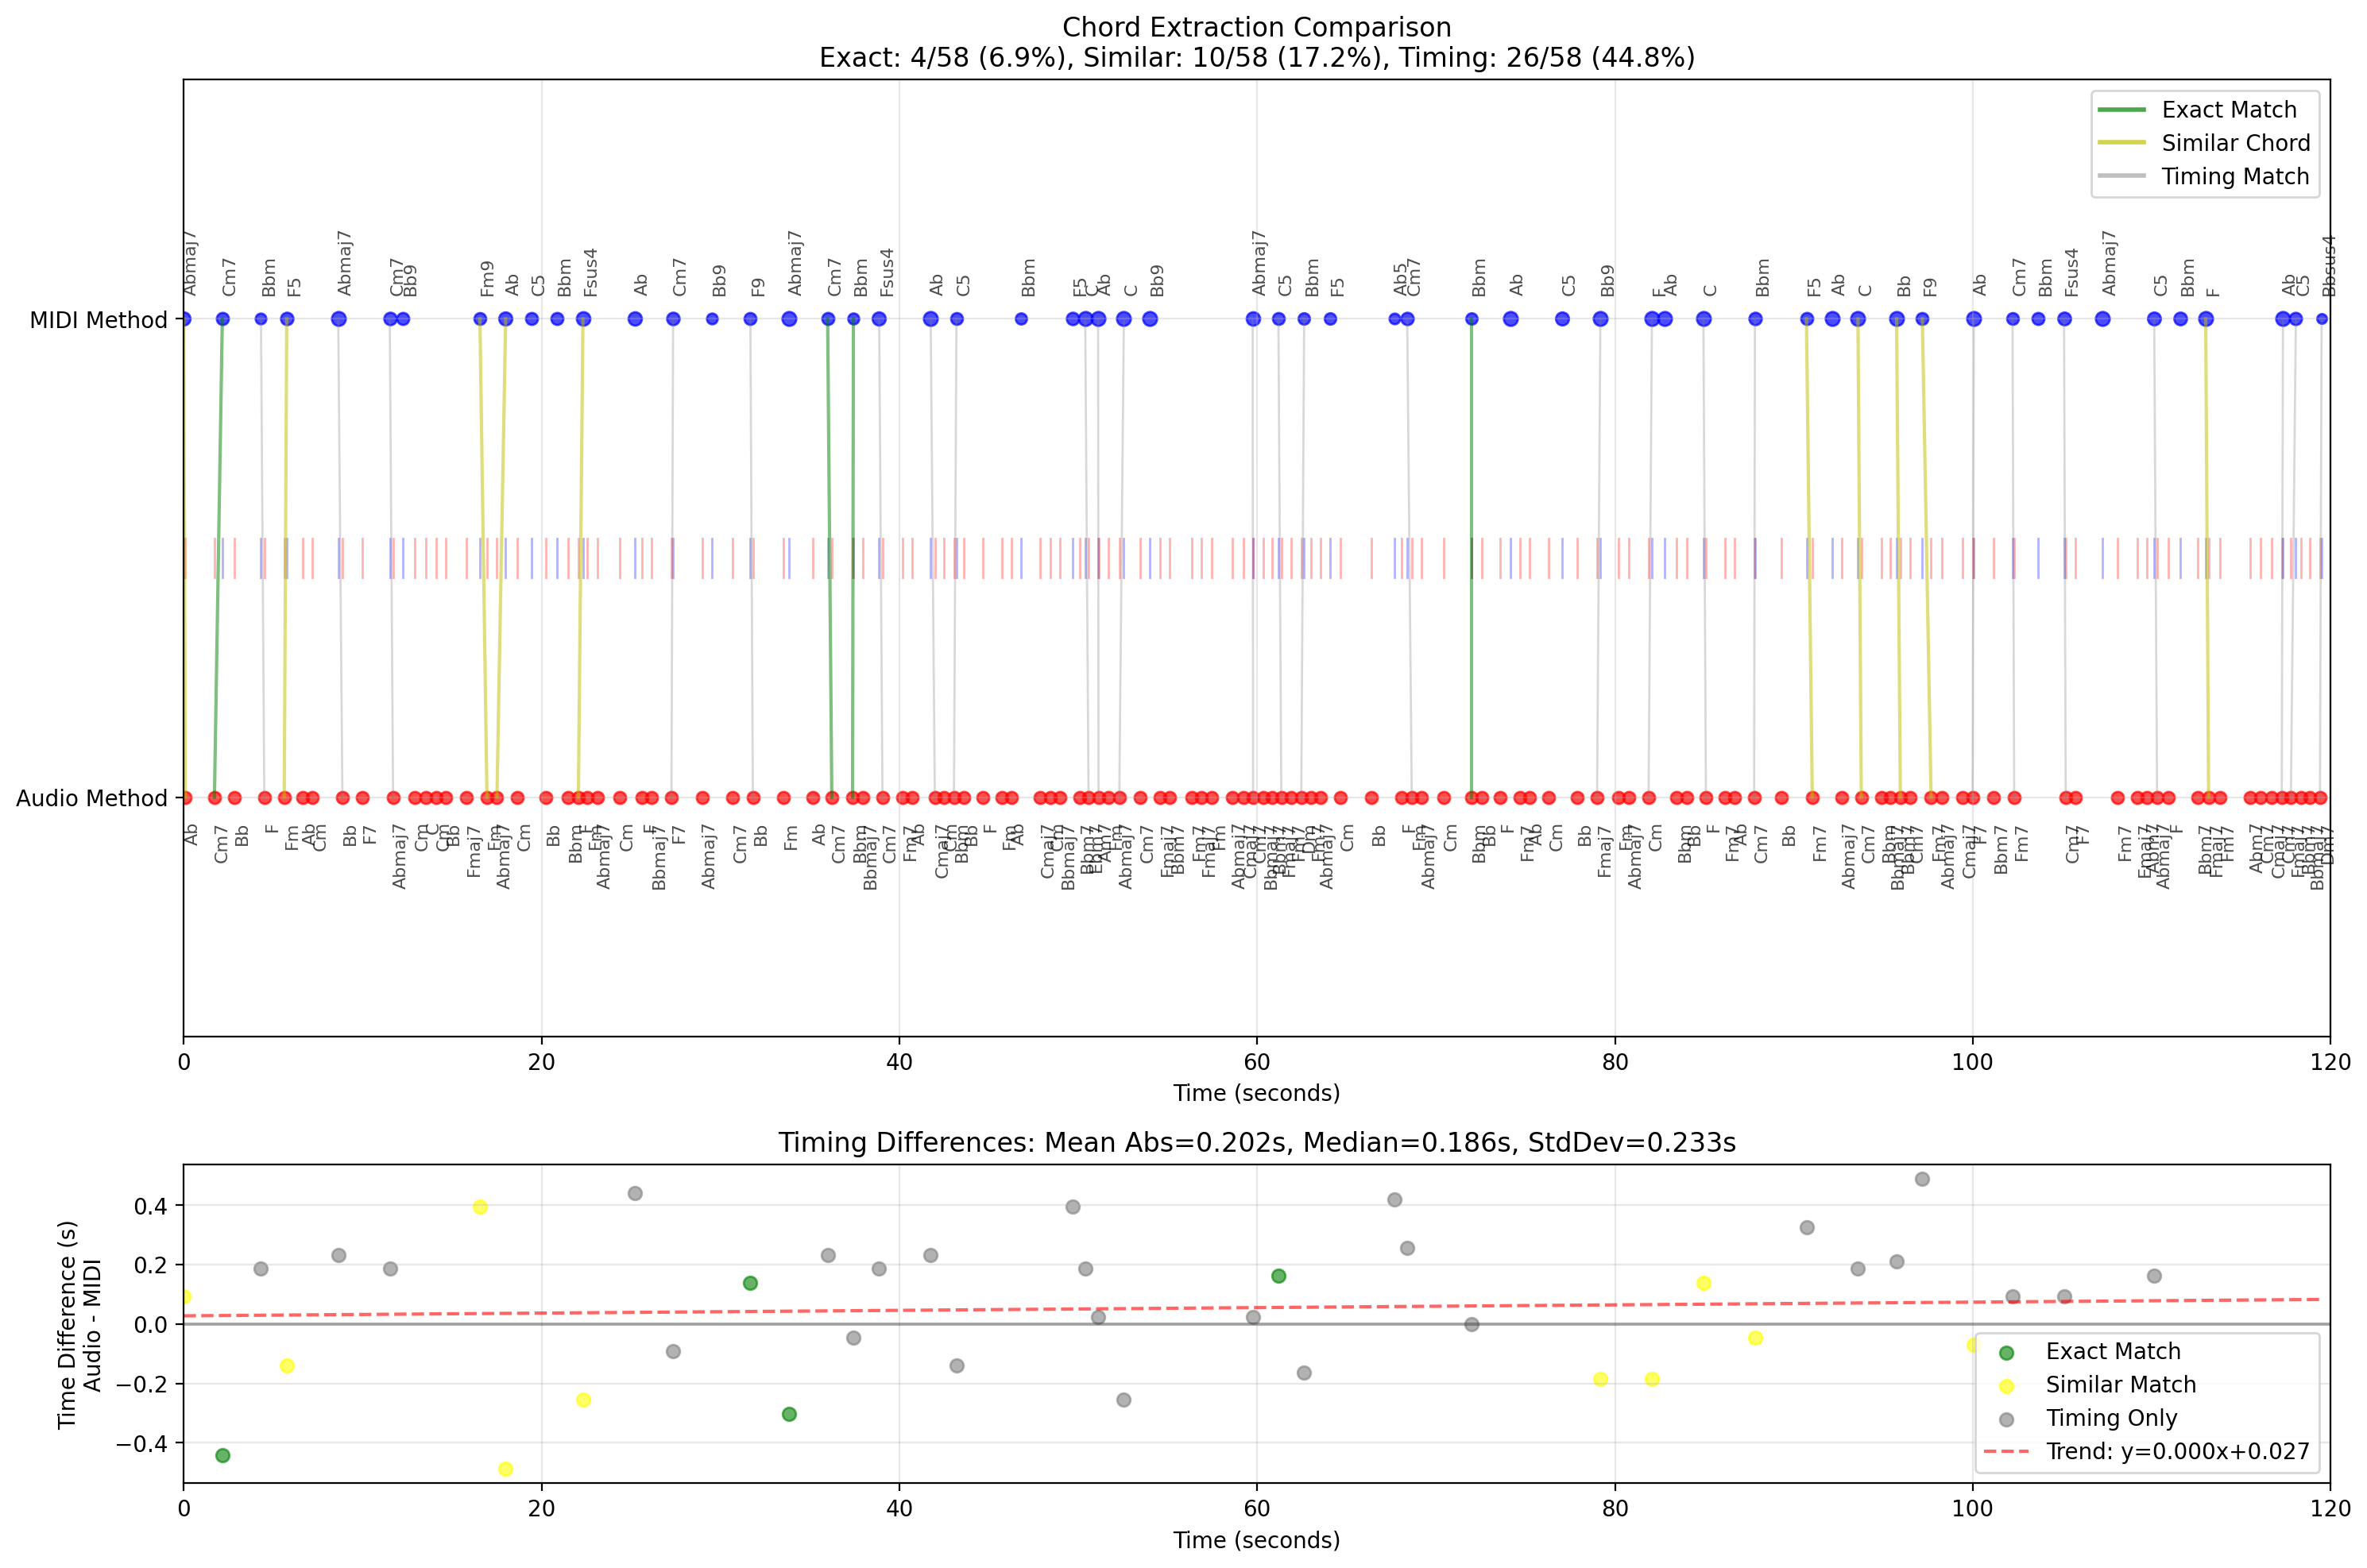

In [8]:
print(chords_midi[:10])
# After extracting chords using both methods
enhanced_chords, consistent_extensions = enhance_midi_chords_with_audio(chords_midi, chords_audio)

# Visualize the enhancements
# visualize_chord_enhancements(chords_midi, enhanced_chords, consistent_extensions)

# Print detailed report
# print_enhancement_report(consistent_extensions)

# Use the enhanced chords for further analysis
stats = compare_chord_extractions(enhanced_chords, chords_audio)

In [10]:
functional_chords = extract_functional_chords(enhanced_chords, tonality)

In [11]:
# Listen to the Bass MIDI file as audio in the notebook
# import pretty_midi
# from IPython.display import Audio, display

# def play_midi_as_audio(midi_path, fs=22050):
#     midi_data = pretty_midi.PrettyMIDI(midi_path)
#     audio = midi_data.fluidsynth(fs=fs)
#     display(Audio(audio, rate=fs))

# play_midi_as_audio(harmony_midi_path)

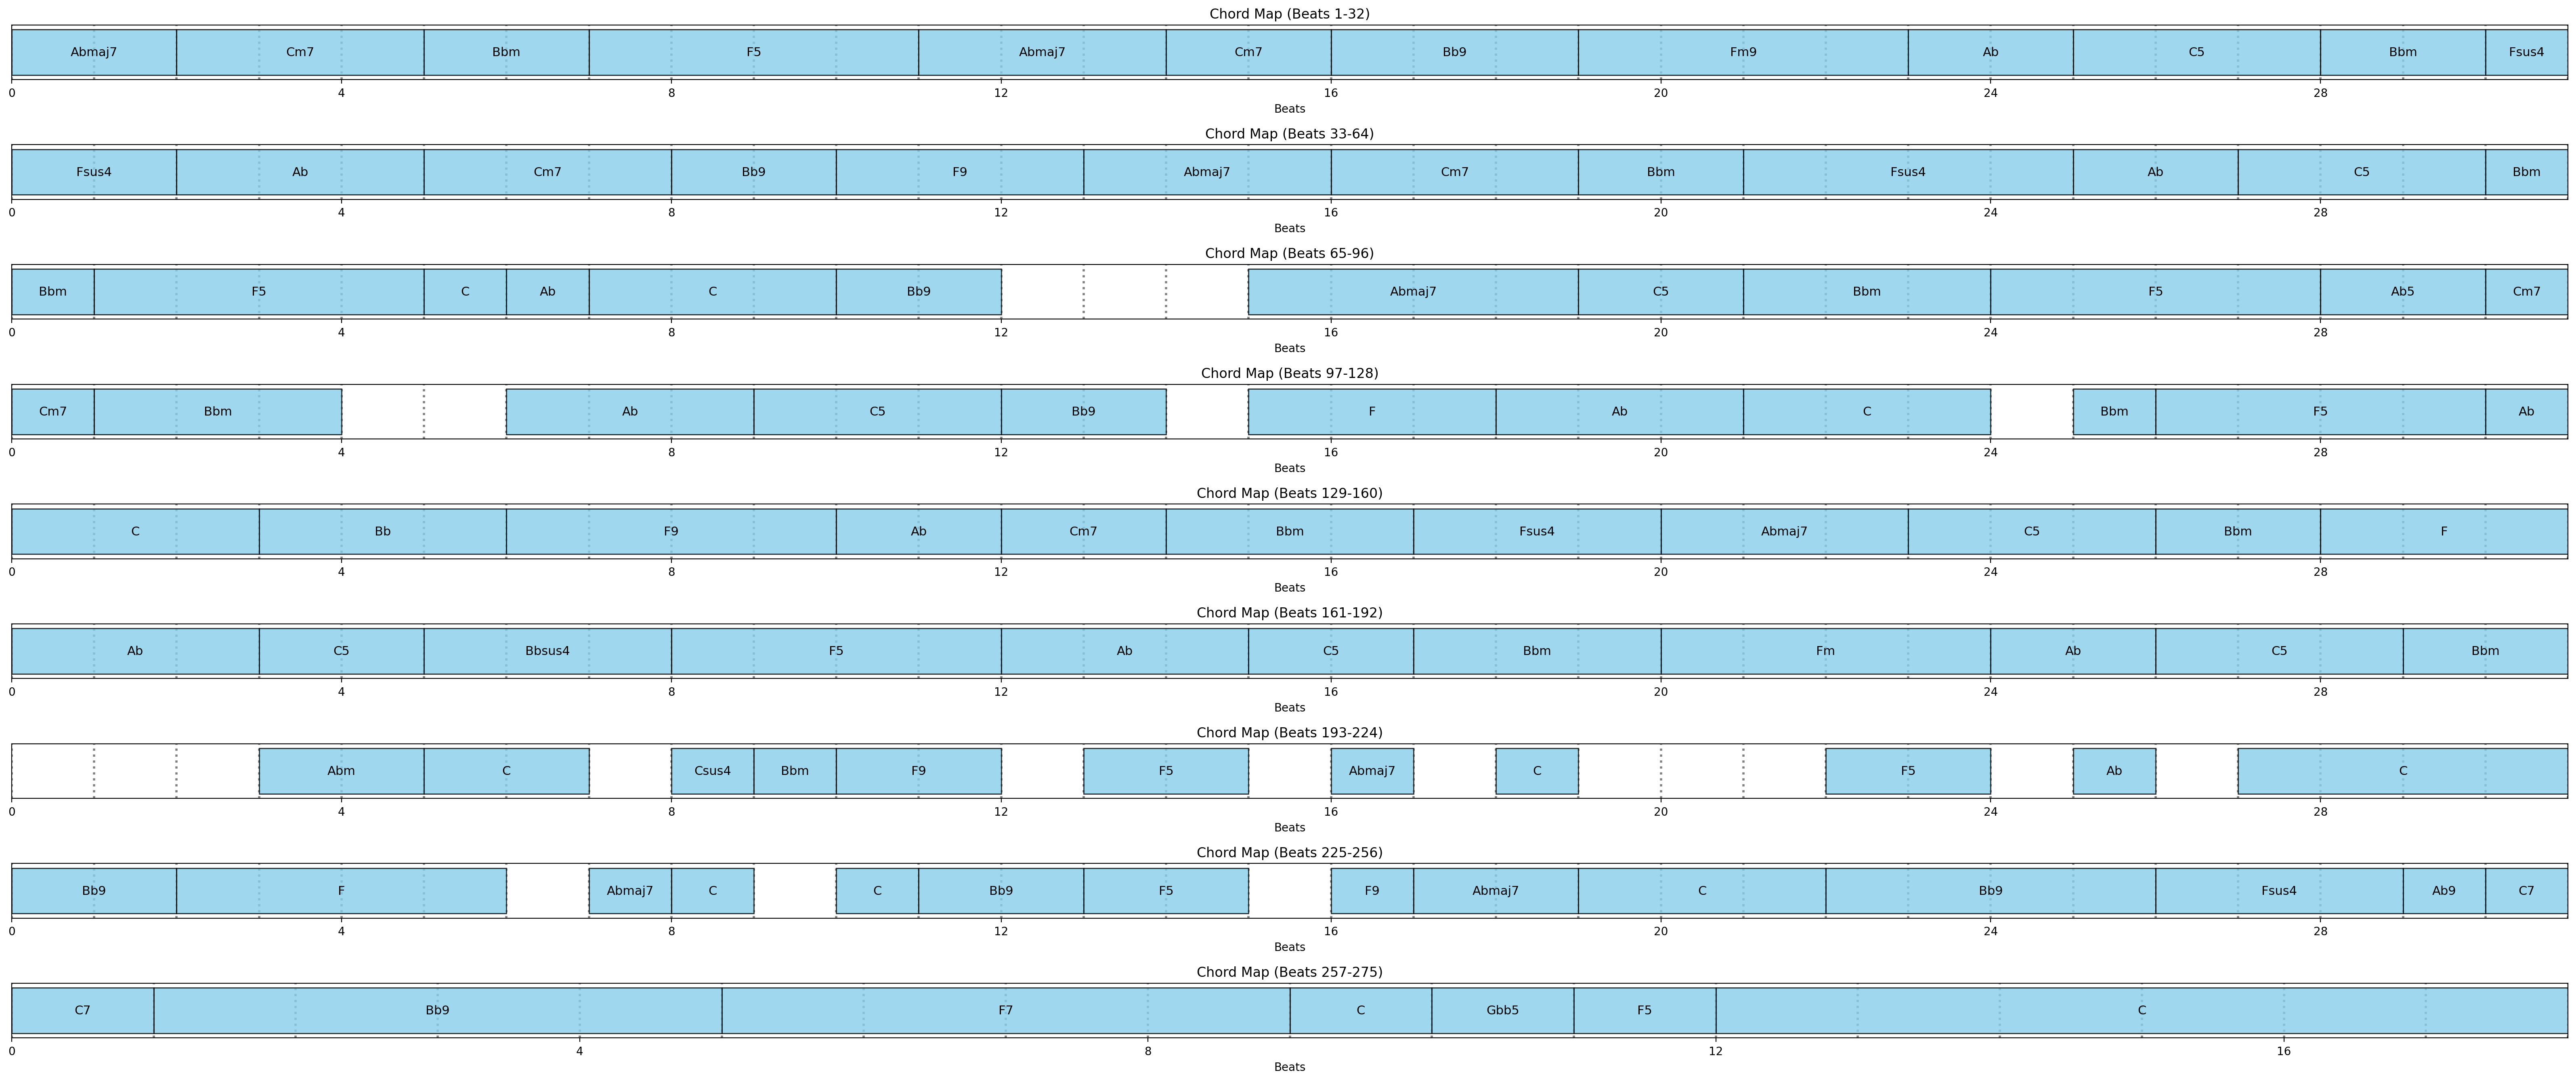

In [12]:
def plot_chord_score_map(enhanced_chords, beats_per_row=16):
    import matplotlib.pyplot as plt
    import numpy as np

    # Prepare data
    chords = []
    starts = []
    ends = []
    for chord in enhanced_chords:
        chords.append(chord['chord_name'])
        starts.append(chord['beat_start'])
        ends.append(chord['beat_end'])

    total_beats = max(ends)
    n_rows = int(np.ceil(total_beats / beats_per_row))
    fig, axes = plt.subplots(n_rows, 1, figsize=(max(12, beats_per_row), 1.5 * n_rows), squeeze=False)

    for row in range(n_rows):
        ax = axes[row, 0]
        row_start = row * beats_per_row + 1
        row_end = min((row + 1) * beats_per_row, total_beats)
        # Draw stronger dotted light gray lines for each beat
        for beat in range(row_start, row_end + 1):
            ax.axvline(beat - row_start, color='gray', linestyle=':', linewidth=2, zorder=0)
        for chord, start, end in zip(chords, starts, ends):
            # Only plot chords that overlap with this row
            if end < row_start or start > row_end:
                continue
            plot_start = max(start, row_start)
            plot_end = min(end, row_end)
            width = plot_end - plot_start
            if width > 0:
                ax.barh(1, width, left=plot_start - row_start, height=0.5, color='skyblue', edgecolor='k', alpha=0.8)
                ax.text((plot_start + plot_end) / 2 - row_start, 1, chord, va='center', ha='center', fontsize=11, color='black', rotation=0)
        ax.set_xlim(0, row_end - row_start)
        ax.set_ylim(0.7, 1.3)
        ax.set_yticks([])
        ax.set_xticks(np.arange(0, row_end - row_start + 1, 4))
        ax.set_xlabel('Beats')
        ax.set_title(f'Chord Map (Beats {row_start}-{row_end})')
    plt.tight_layout()
    plt.show()

# --- Main logic ---
plot_chord_score_map(enhanced_chords, beats_per_row=32)